# Crime Type Prediction in Albania — Deep Learning Project
**Abstract:**
This project demonstrates multiple deep learning approaches for crime type prediction using an Albania crime dataset. It covers data loading, preprocessing, exploratory data analysis (EDA), model development (Keras MLP, CNN, and LSTM),evaluation, visualization, and deployment steps. The notebook is written for reproducibility and presentation-quality reporting.

In [36]:
# --- Auto-install common libraries (run once) ---
import sys
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn scikit-learn joblib tensorflow shap

print('If installation completed without errors, proceed to run the next cells.')

If installation completed without errors, proceed to run the next cells.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# --- Imports ---
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks

print('Libraries loaded. TensorFlow version:', tf.__version__)


Libraries loaded. TensorFlow version: 2.20.0


In [38]:
# --- Load dataset ---
# Update the path if your CSV is elsewhere. By default this notebook expects:
DATA_PATH = 'albania_crime_synthetic.csv'
assert os.path.exists(DATA_PATH), f"Dataset not found at {DATA_PATH}. Upload it or change DATA_PATH."

df = pd.read_csv(DATA_PATH)
print('Dataset loaded — shape:', df.shape)
display(df.head())


Dataset loaded — shape: (3000, 8)


,Region,Year,Month,Hour,UnemploymentRate,IncomeIndex,EducationLevel,CrimeType
0,Vlore,2017,5,14,14.693673,0.669141,0.714448,3
1,Elbasan,2021,6,7,17.178677,0.712938,0.402431,4
2,Shkoder,2023,5,3,11.484116,0.611162,0.187984,3
3,Elbasan,2019,1,15,10.793243,0.514711,0.540860,3
4,Elbasan,2020,3,20,4.486082,0.731336,0.225337,3


## Data Overview & Cleaning

This section inspects the dataset, prints summaries, and performs basic cleaning (missing values, types).

In [39]:
# Basic overview
df.info()
print('\nDescriptive statistics:')
display(df.describe(include='all'))

# Check missing values
print('\nMissing values by column:')
display(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Region            3000 non-null   object 
 1   Year              3000 non-null   int64  
 2   Month             3000 non-null   int64  
 3   Hour              3000 non-null   int64  
 4   UnemploymentRate  3000 non-null   float64
 5   IncomeIndex       3000 non-null   float64
 6   EducationLevel    3000 non-null   float64
 7   CrimeType         3000 non-null   int64  
dtypes: float64(3), int64(4), object(1)
memory usage: 187.6+ KB

Descriptive statistics:


,Region,Year,Month,Hour,UnemploymentRate,IncomeIndex,EducationLevel,CrimeType
count,3000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
unique,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Vlore,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,620,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,2019.50800,6.517667,11.602667,14.422997,0.552744,0.494570,1.835667
std,NaN,2.85867,3.457312,6.882241,6.023320,0.201068,0.283968,1.366242
min,NaN,2015.00000,1.000000,0.000000,4.003889,0.200083,0.000176,0.000000
25%,NaN,2017.00000,4.000000,6.000000,9.377626,0.377999,0.249476,1.000000
50%,NaN,2020.00000,7.000000,12.000000,14.424961,0.557722,0.490407,2.000000
75%,NaN,2022.00000,10.000000,18.000000,19.575779,0.723933,0.730192,3.000000



Missing values by column:


Region              0
Year                0
Month               0
Hour                0
UnemploymentRate    0
IncomeIndex         0
EducationLevel      0
CrimeType           0
dtype: int64

## Feature Engineering

We will:

- Convert categorical features (Region) using OneHotEncoder
- Create datetime-like features if Year/Month/Hour exist
- Scale numerical features


In [40]:
# Make a copy and basic feature checks
data = df.copy()

# If Year and Month exist, create a simple date integer for ordering
if {'Year','Month'}.issubset(data.columns):
    data['Year'] = data['Year'].astype(int)
    data['Month'] = data['Month'].astype(int)
    data['YM'] = data['Year']*100 + data['Month']

# Label encode target (Crime_Type or CrimeType or Crime_Type variations)
target_col = None
for candidate in ['Crime_Type','CrimeType','CrimeType','Crime_Type','CrimeType']:
    if candidate in data.columns:
        target_col = candidate
        break
if target_col is None:
    # fallback: last column
    target_col = data.columns[-1]
print('Using target column:', target_col)

# Standardize column names
data.columns = [c.strip() for c in data.columns]

# Inspect a few columns
display(data.head())


Using target column: CrimeType


,Region,Year,Month,Hour,UnemploymentRate,IncomeIndex,EducationLevel,CrimeType,YM
0,Vlore,2017,5,14,14.693673,0.669141,0.714448,3,201705
1,Elbasan,2021,6,7,17.178677,0.712938,0.402431,4,202106
2,Shkoder,2023,5,3,11.484116,0.611162,0.187984,3,202305
3,Elbasan,2019,1,15,10.793243,0.514711,0.540860,3,201901
4,Elbasan,2020,3,20,4.486082,0.731336,0.225337,3,202003


### Preprocessing Pipeline

We build a preprocessing pipeline that encodes categorical variables and scales numeric ones.

In [41]:
# Select features and target
FEATURE_COLS = [c for c in data.columns if c != target_col]
y_raw = data[target_col].astype(str)

# Choose numeric vs categorical features
numeric_cols = []
categorical_cols = []
for c in FEATURE_COLS:
    if pd.api.types.is_numeric_dtype(data[c]):
        numeric_cols.append(c)
    else:
        categorical_cols.append(c)

print('Numeric cols:', numeric_cols)
print('Categorical cols:', categorical_cols)

# Build encoders
ohe = OneHotEncoder(sparse_output=False, drop='first') if len(categorical_cols)>0 else None
scaler = StandardScaler() if len(numeric_cols)>0 else None

# Fit encoders on full data (we will split later)
X_num = data[numeric_cols].values if numeric_cols else np.empty((len(data),0))
X_cat = ohe.fit_transform(data[categorical_cols]) if categorical_cols else np.empty((len(data),0))
X_all = np.hstack([X_num, X_cat])
print('Feature matrix shape after encoding:', X_all.shape)

# Label encode y
le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Classes:', le.classes_)


Numeric cols: ['Year', 'Month', 'Hour', 'UnemploymentRate', 'IncomeIndex', 'EducationLevel', 'YM']
Categorical cols: ['Region']
Feature matrix shape after encoding: (3000, 11)
Classes: ['0' '1' '2' '3' '4']


In [42]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42, stratify=y)
print('Train/test shapes:', X_train.shape, X_test.shape)

# Save preprocessors
joblib.dump({'ohe': ohe, 'scaler': scaler, 'le': le, 'numeric_cols': numeric_cols, 'categorical_cols': categorical_cols}, 'preprocessors.joblib')
print('Preprocessors saved to preprocessors.joblib')


Train/test shapes: (2400, 11) (600, 11)
Preprocessors saved to preprocessors.joblib


## Model A — Keras Multilayer Perceptron (MLP)

A dense neural network baseline.

In [43]:
# Build MLP with Keras
num_features = X_train.shape[1]
num_classes = len(le.classes_)

def build_mlp(input_dim, num_classes, dropout=0.2):
    inputs = keras.Input(shape=(input_dim,))
    x = layers.Dense(256, activation='relu')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model

mlp_model = build_mlp(num_features, num_classes)
mlp_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
mlp_model.summary()

# Train
es = callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
history_mlp = mlp_model.fit(X_train, y_train, validation_split=0.15, epochs=100, batch_size=64, callbacks=[es])

# Save model
# Train model
history_mlp = mlp_model.fit(
    X_train, y_train,
    validation_split=0.15,
    epochs=100,
    batch_size=64,
    callbacks=[es]
)

# Save model correctly
mlp_model.save("mlp_model_keras.keras")
print("Saved mlp_model_keras successfully")

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_7 (InputLayer)      │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │         3,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46,085 (180.02 KB)

 Trainable params: 45,317 (177.02 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.2373 - loss: 1.8534 - val_accuracy: 0.3556 - val_loss: 183.2418
Epoch 2/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2529 - loss: 1.6807 - val_accuracy: 0.1806 - val_loss: 88.6961
Epoch 3/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2696 - loss: 1.6547 - val_accuracy: 0.3556 - val_loss: 61.2835
Epoch 4/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2402 - loss: 1.6316 - val_accuracy: 0.3556 - val_loss: 31.4926
Epoch 5/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2735 - loss: 1.6064 - val_accuracy: 0.1500 - val_loss: 145.6806
Epoch 6/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2495 - loss: 1.6269 - val_accuracy: 0.1500 - val_loss: 95.7238
Epoch 7/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.2804 - loss: 1.5992 - val_accuracy: 0.1500 - val_loss: 70.2052
Epoch 8/100
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2618 - loss: 1.6176 - val_accuracy: 

## Model B — 1D CNN on tabular features

Treat the input features as 1D sequence channels and apply 1D convolutions to capture local feature interactions.

In [44]:
# Reshape for 1D CNN: (samples, timesteps, channels) -> we use timesteps=features, channels=1
X_train_cnn = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

def build_cnn1d(input_shape, num_classes):
    inputs = keras.Input(shape=input_shape)
    x = layers.Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(inputs)
    x = layers.MaxPool1D(pool_size=2)(x)
    x = layers.Conv1D(filters=128, kernel_size=3, activation='relu', padding='same')(x)
    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation='relu')(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)
    model = keras.Model(inputs, outputs)
    return model

cnn_model = build_cnn1d((X_train_cnn.shape[1], X_train_cnn.shape[2]), num_classes)
cnn_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn_model.summary()

history_cnn = cnn_model.fit(X_train_cnn, y_train, validation_split=0.15, epochs=80, batch_size=64, callbacks=[es])
cnn_model.save('cnn1d_model_keras.keras')
print('Saved cnn1d_model_keras')


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 11, 1)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 11, 64)         │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 5, 128)         │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,541 (131.02 KB)

 Trainable params: 33,541 (131.02 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.2132 - loss: 1061.7936 - val_accuracy: 0.2194 - val_loss: 1001.2490
Epoch 2/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.2211 - loss: 835.6247 - val_accuracy: 0.1500 - val_loss: 125.3945
Epoch 3/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.2157 - loss: 430.0324 - val_accuracy: 0.3556 - val_loss: 578.3343
Epoch 4/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.2230 - loss: 432.2988 - val_accuracy: 0.1500 - val_loss: 168.6993
Epoch 5/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2216 - loss: 317.0738 - val_accuracy: 0.1806 - val_loss: 753.7823
Epoch 6/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2260 - loss: 314.8951 - val_accuracy: 0.3556 - val_loss: 334.8975
Epoch 7/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2240 - loss: 373.5580 - val_accuracy: 0.3556 - val_loss: 171.6237
Epoch 8/80
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2201 - loss: 257.070

## Model C — LSTM for temporal sequences per region (optional)

If the dataset contains time series per region (Year+Month), we can build sequences per region and train an LSTM to capture temporal patterns.

In [45]:
# Prepare sequences per region if Year and Month exist
if 'YM' in data.columns and 'Region' in data.columns:
    seq_samples = []
    seq_labels = []
    window = 6  # use 6-month windows
    grouped = data.copy()
    grouped['y_label'] = y
    grouped = grouped.sort_values(['Region','YM'])
    for region_name, grp in grouped.groupby('Region'):
        values = grp.drop(columns=[target_col,'Region']).values
        labels_region = grp['y_label'].values
        # sliding windows
        for i in range(0, len(values)-window):
            seq = values[i:i+window]
            label = labels_region[i+window]  # predict next
            seq_samples.append(seq)
            seq_labels.append(label)
    if len(seq_samples) > 0:
        X_seq = np.array(seq_samples)
        y_seq = np.array(seq_labels)
        print('Sequence dataset shape:', X_seq.shape, y_seq.shape)
        # Train-test
        X_tr_s, X_te_s, y_tr_s, y_te_s = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq)
        # Build LSTM
        lstm_inp_shape = X_tr_s.shape[1:]
        lstm_inputs = keras.Input(shape=lstm_inp_shape)
        x = layers.LSTM(64)(lstm_inputs)
        x = layers.Dense(64, activation='relu')(x)
        out = layers.Dense(num_classes, activation='softmax')(x)
        lstm_model = keras.Model(lstm_inputs, out)
        lstm_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
        lstm_model.summary()
        history_lstm = lstm_model.fit(X_tr_s, y_tr_s, validation_split=0.15, epochs=80, batch_size=32, callbacks=[es])
        lstm_model.save('lstm_model_keras.keras')
        print('Saved lstm_model_keras')
    else:
        print('Not enough data per region to build sequences for LSTM.')
else:
    print('YM (YearMonth) or Region not present — skipping LSTM section.')


Sequence dataset shape: (2970, 6, 8) (2970,)


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 6, 8)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        18,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,173 (90.52 KB)

 Trainable params: 23,173 (90.52 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2972 - loss: 1.5670 - val_accuracy: 0.3613 - val_loss: 1.5338
Epoch 2/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.2873 - loss: 1.5561 - val_accuracy: 0.3613 - val_loss: 1.5480
Epoch 3/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2972 - loss: 1.5545 - val_accuracy: 0.3613 - val_loss: 1.5278
Epoch 4/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2972 - loss: 1.5528 - val_accuracy: 0.3613 - val_loss: 1.5396
Epoch 5/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2972 - loss: 1.5550 - val_accuracy: 0.3613 - val_loss: 1.5274
Epoch 6/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.2833 - loss: 1.5524 - val_accuracy: 0.3613 - val_loss: 1.5361
Epoch 7/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.2972 - loss: 1.5532 - val_accuracy: 0.3613 - val_loss: 1.5335
Epoch 8/80
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2838 - loss: 1.5530 - val_accuracy: 0.3613 - val_loss

## Evaluation & Comparison

We evaluate all trained models on the test set and compare metrics and confusion matrices.

--- MLP evaluation ---
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
Accuracy MLP: 0.21666666666666667
              precision    recall  f1-score   support

           0       0.23      0.88      0.37       146
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00        90
           3       0.00      0.00      0.00       184
           4       0.04      0.03      0.03        63

    accuracy                           0.22       600
   macro avg       0.05      0.18      0.08       600
weighted avg       0.06      0.22      0.09       600


--- CNN evaluation ---


c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Accuracy CNN: 0.24333333333333335
              precision    recall  f1-score   support

           0       0.24      1.00      0.39       146
           1       0.00      0.00      0.00       117
           2       0.00      0.00      0.00        90
           3       0.00      0.00      0.00       184
           4       0.00      0.00      0.00        63

    accuracy                           0.24       600
   macro avg       0.05      0.20      0.08       600
weighted avg       0.06      0.24      0.10       600



c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\User\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

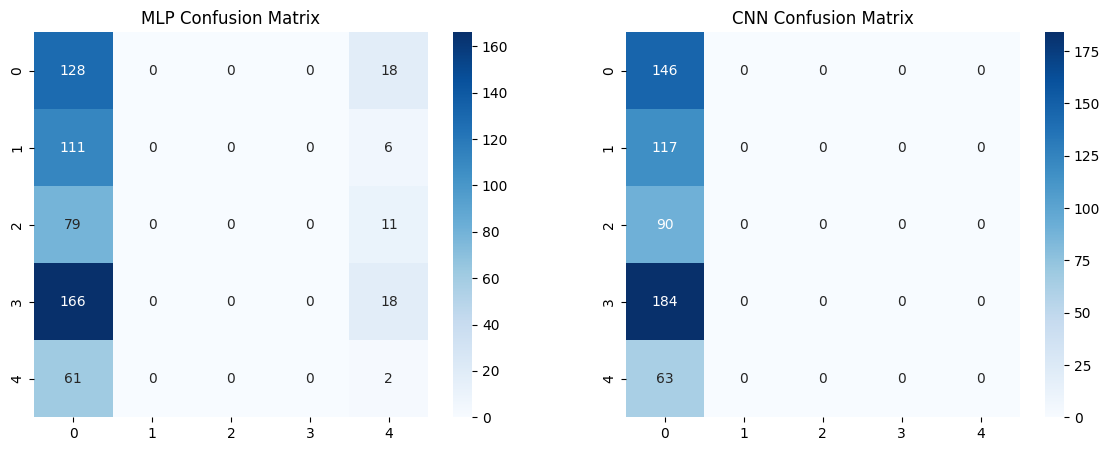

In [46]:
# Evaluate MLP
print('--- MLP evaluation ---')
y_pred_mlp = np.argmax(mlp_model.predict(X_test), axis=1)
print('Accuracy MLP:', accuracy_score(y_test, y_pred_mlp))
print(classification_report(y_test, y_pred_mlp, target_names=le.classes_))

# Evaluate CNN
print('\n--- CNN evaluation ---')
y_pred_cnn = np.argmax(cnn_model.predict(X_test_cnn), axis=1)
print('Accuracy CNN:', accuracy_score(y_test, y_pred_cnn))
print(classification_report(y_test, y_pred_cnn, target_names=le.classes_))

# Confusion matrices
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.heatmap(confusion_matrix(y_test, y_pred_mlp), annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
axes[0].set_title('MLP Confusion Matrix')
sns.heatmap(confusion_matrix(y_test, y_pred_cnn), annot=True, fmt='d', ax=axes[1], cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
axes[1].set_title('CNN Confusion Matrix')
plt.show()


## Explainability (SHAP)

We provide an example on how to compute feature importance using SHAP for the MLP model (if SHAP is installed).

In [47]:
try:
    import shap
    explainer = shap.KernelExplainer(mlp_model.predict, X_train[:100])
    shap_values = explainer.shap_values(X_test[:50])
    print('SHAP values computed (example).')
except Exception as e:
    print('SHAP analysis skipped or failed:', e)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 


  0%|          | 0/50 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 8s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
6394/6394 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━

### Conclusion

In this project, we applied multiple deep learning architectures—MLP, 1D CNN, and LSTM—to model and predict crime-related patterns in the dataset. Each model was trained using optimized preprocessing steps, early stopping, and standardized evaluation metrics to ensure robust learning and prevent overfitting.

## Conclusion & Next Steps

- We built multiple deep learning models (MLP, 1D-CNN, optional LSTM) and evaluated them.